# Mentoring 3 - Fraud Analytics
---
Mohammad Rifqi Zein \
Mentoring Session - Job Preparation Program - Pacmann AI

In [2]:
# Load package
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Case Description
---

- You work as a data scientist for an online retail company. 
- The company is at risk of financial losses due to fraudulent transactions, which could lead to instability in its operations. 
- To reduce these losses and improve profitability, your objective is to identify fraudulent transactions as early as possible in the process, while minimizing the effect of false transactions on the company’s revenue.
- Your task is to develop a machine learning-based solution that can detect fraudulent activities. 
- These flagged transactions can then be investigated further, helping to prevent fraudulent ones from being processed and approved.
- [Download dataset here](https://drive.google.com/file/d/1b4FzZaMgXjGlgsM5JN6S3eFGsXvexaNl/view?usp=sharing) 


## 2. Dataset Description
---

|Column|Description|
|:--|:--|
|`Transaction ID`|A unique identifier for each transaction.|
|`Transaction Amount`|The total amount of money exchanged in the transaction.|
|`Payment Method`|The method used to complete the transaction (e.g., credit card, PayPal, etc.).|
|`Product Category`|The category of the product involved in the transaction.|
|`Quantity`|The number of products involved in the transaction.|
|`Customer Age`|The age of the customer making the transaction.|
|`Device Used`|The type of device used to make the transaction (e.g., mobile, desktop).|
|`Is Fraudulent`|A binary indicator of whether the transaction is fraudulent (1 for fraudulent, 0 for legitimate).|
|`Account Age Days`|The age of the customer's account in days at the time of the transaction.|
|`Transaction Hour`|The hour of the day when the transaction occurred.|

## 3. The Tools
---

You can use Python to complete this exercise.

## 4. Your Task
---

## Question 1

Prepare the dataset before further analysis and modeling. This step ensures that the dataset is well-structured. \
Task:
- Inspect missing values, duplicate records, invalid and inconsistencies, and handle them if any.
- Split the dataset into features (X) and target variable (y), where the target is “Is Fraudulent” (1 for fraudulent, 0 for legitimate).
- Split the dataset into training, validation and testing data. The training data should come from 60% of the original data, the validation data from 20% of original data, and testing data from 20% of the original data.

### **Importing Data**

In [13]:
# read dataset function
def read_data(path):
    """
    Reads a CSV file at the given path, removes any duplicate rows,
    and returns its contents as a pandas DataFrame.

    Parameters
    ----------
    path : str
        The sample data input path (csv format)

    Return
    ------
    df : pd.DataFrame
        The sample data input
    """
    # Read data
    df = pd.read_csv(path)

    # Validate
    print('Data shape:', df.shape)

    return df

In [14]:
# Dataset name / Path
path = 'fraud_ecom_transaction_data.csv'

# Read the data
df = read_data(path = path)
df.head()

Data shape: (23634, 10)


,Transaction ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Device Used,Is Fraudulent,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,42.32,PayPal,electronics,1,40,desktop,0,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,301.34,credit card,electronics,3,35,tablet,0,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,340.32,debit card,toys & games,5,29,desktop,0,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,95.77,credit card,electronics,5,45,mobile,0,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,77.45,credit card,clothing,5,42,desktop,0,116,15


Kemudian kita cek missing values dan duplicates.

In [16]:
print("Number of missing values:\n", df.isnull().sum())
print("Number of duplicates:", df.duplicated().sum())

Number of missing values:
 Transaction ID        0
Transaction Amount    0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Device Used           0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64
Number of duplicates: 0


Tidak ada data yang hilang ataupun duplikat. \
Kemudian kita cek apakah semua nilai numerik bernilai positif (karena tidak mungkin umur dan jumlah uang bernilai negatif) dan cek tiap kategori dalam data kategorikal serta cek juga apakah semua nilai `Is Fraudulent` bernilai 0 dan 1.

In [18]:
numeric_cols = ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Transaction Hour']
negative_counts = (df[numeric_cols] < 0).sum()

print("Number of negative values:")
print(negative_counts)

print("Unique values of 'Payment Method':", df['Payment Method'].unique())
print("Unique values of 'Product Category':", df['Product Category'].unique())
print("Unique values of 'Device Used':", df['Device Used'].unique())
print("Unique values of 'Is Fraudulent':", df['Is Fraudulent'].unique())

Number of negative values:
Transaction Amount    0
Quantity              0
Customer Age          1
Account Age Days      0
Transaction Hour      0
dtype: int64
Unique values of 'Payment Method': ['PayPal' 'credit card' 'debit card' 'bank transfer']
Unique values of 'Product Category': ['electronics' 'toys & games' 'clothing' 'home & garden' 'health & beauty']
Unique values of 'Device Used': ['desktop' 'tablet' 'mobile']
Unique values of 'Is Fraudulent': [0 1]


Ternyata ada nilai Age yang bernilai negatif. Coba kita analisis lebih lanjut.

In [20]:
df['Customer Age'].sort_values()

12919    -2
11200     0
13728     0
14869     0
20755     0
         ..
16214    69
20276    70
20737    71
499      73
17581    73
Name: Customer Age, Length: 23634, dtype: int64

Ada nilai Customer Age yang negatif dan 0 (tidak mungkin). Jika jumlahnya hanya sedikit, data ini akan kita hapus.

In [22]:
df[df['Customer Age'] <=0]

,Transaction ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Device Used,Is Fraudulent,Account Age Days,Transaction Hour
4157,99d127ce-995e-49a1-94ed-da7046822cf7,150.70,debit card,toys & games,5,0,tablet,0,357,15
11200,c8d09263-fce5-42aa-be68-0267eb304b5b,103.83,debit card,electronics,5,0,tablet,0,81,2
12919,7fab7db0-e4d2-4b51-98f3-bb17b5153224,190.76,PayPal,health & beauty,3,-2,desktop,0,253,15
13728,840ef430-f43f-478b-8e7d-be28f2e9e07e,10.44,debit card,toys & games,4,0,desktop,0,33,19
14869,d7421b58-7184-499f-bc79-3ce923d0563d,798.07,credit card,home & garden,1,0,desktop,0,340,17
20224,c542eac6-5520-4c44-b895-4013f2e650d8,106.67,credit card,health & beauty,4,0,mobile,0,222,13
20755,25adc05f-1048-4457-a66c-75029221cf7d,22.26,bank transfer,health & beauty,2,0,mobile,0,324,17
22065,05c46572-1a4b-4038-b4f7-cf096b5ba274,172.29,debit card,clothing,3,0,mobile,0,222,21
22268,d5c01367-f97d-461f-b238-32a1cee8a2b6,177.24,debit card,toys & games,2,0,mobile,0,330,15


In [23]:
# kita hapus data yang memiliki umur negatif dan 0
df = df[df['Customer Age'] > 0]
df.shape

(23625, 10)

### **Splitting Data**

Kemudian, kita akan melakukan splitting data terlebih dahulu agar tidak terjadi data leaking ketika training dan evaluasi model.

**Split Input & Output**

In [27]:
# function split input and output
def split_input_output(data, target_column):
    """
    Function to split input (x) and output (y)

    Parameters
    ----------
    data : pd.DataFrame
        The sample data input

    target_column : str
        The output column name

    Return
    ------
    X : pd.DataFrame
        input data

    y : pd.DataFrame
        output data
    """
    X = data.drop(columns = target_column)
    y = data[target_column]

    # Validate
    print('X shape:', X.shape)
    print('y shape :', y.shape)

    return X, y

In [28]:
# Split input x and output y
X, y = split_input_output(data = df,
                          target_column = "Is Fraudulent")

# Show 5 first rows of input
X.head()

X shape: (23625, 9)
y shape : (23625,)


,Transaction ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Device Used,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,42.32,PayPal,electronics,1,40,desktop,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,301.34,credit card,electronics,3,35,tablet,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,340.32,debit card,toys & games,5,29,desktop,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,95.77,credit card,electronics,5,45,mobile,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,77.45,credit card,clothing,5,42,desktop,116,15


In [29]:
# Show 5 first rows of output
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Is Fraudulent, dtype: int64

In [30]:
# check data dimension
n_samples, n_features = X.shape

# print number samples and features
print(f"Number of samples  : {n_samples}")
print(f"Number of features : {n_features}")

Number of samples  : 23625
Number of features : 9


In [31]:
# check data features name
features_names = X.columns

# print name of features
print(f"name of features : {features_names}")

name of features : Index(['Transaction ID', 'Transaction Amount', 'Payment Method',
       'Product Category', 'Quantity', 'Customer Age', 'Device Used',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')


**Split Train, Valid, and Test Data**

In [33]:
from sklearn.model_selection import train_test_split

def split_train_valid_test(X, y, test_size, valid_size, stratify, random_state=42):
    """
    Split data into train & test

    Parameters
    ----------
    X : pd.DataFrame
        The input data

    y : pd.Series
        The output data

    test_size : float
        The proportion of number of test data to total data

    valid_size : float
        The proportion of number of validation data to total data

    stratify : pd.Series
        Reference to stratify the splitting

    random_state : int, default=42
        The random seed, for reproducibility

    Returns
    -------
    X_train : pd.DataFrame
        The input train data

    X_test : pd.DataFrame
        The input test data

    y_train : pd.Series
        The output train data

    y_test : pd.Series
        The output test data
    """
    # Split the data
    X_train, X_not_train, y_train, y_not_train = train_test_split(
        X,
        y,
        test_size = test_size + valid_size,
        stratify = stratify,
        random_state = random_state
    )

    # Then, split valid and test from not_train
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_not_train,
        y_not_train,
        test_size = valid_size/(test_size + valid_size),
        stratify = y_not_train,
        random_state = random_state
    )

    # Validate
    print('X train shape:', X_train.shape)
    print('y train shape:', y_train.shape)
    print('X valid shape :', X_valid.shape)
    print('y valid shape :', y_valid.shape)
    print('X test shape :', X_test.shape)
    print('y test shape :', y_test.shape)

    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [34]:
# Run the code
splitted_data = split_train_valid_test(
    X = X,
    y = y,
    test_size = 0.2,
    valid_size = 0.2,
    stratify = y,
    random_state = 42
)

X_train, X_valid, X_test, y_train, y_valid, y_test = splitted_data

X train shape: (14175, 9)
y train shape: (14175,)
X valid shape : (4725, 9)
y valid shape : (4725,)
X test shape : (4725, 9)
y test shape : (4725,)


**Create EDA Dataset**

In [36]:
# create EDA dataset
eda_df = pd.concat([X_train, y_train],
                   axis=1)
eda_df.head()

,Transaction ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Device Used,Account Age Days,Transaction Hour,Is Fraudulent
8692,c30065ef-0aa6-4f1e-9057-dddaf95f0af5,223.89,bank transfer,home & garden,2,39,tablet,212,13,0
1914,674b2bf7-a842-4cbc-8ea0-19f2acbc3aa4,227.18,PayPal,clothing,3,34,tablet,143,19,0
20699,79735e90-c04e-4b48-bcb6-556714025782,268.61,bank transfer,home & garden,4,36,mobile,331,0,0
17198,e2f7760e-0518-4ed1-9f32-6b4dd5da1dd5,59.27,PayPal,toys & games,5,26,desktop,354,12,0
20905,4594eb03-88e4-4d6b-acc8-a9648621ec7a,1072.77,debit card,toys & games,3,35,tablet,182,6,0


In [37]:
# Print train set shape after concat
print('eda_df shape:', eda_df.shape)

eda_df shape: (14175, 10)


## Question 2

Perform Exploratory Data Analysis to understand data better. Identify patterns, correlations, and potential outliers that could indicate fraudulent behavior. \
Task:
- Use at least four visualizations, including both histograms and boxplots, to identify patterns and compare feature distributions between fraud and non-fraud cases.
- Analyze the relationships between features using correlation.
- Provide at least four key insights from the EDA that could help identify fraudulent transactions quickly.

### Exploratory Data Analysis

Pertama, kita lihat distribusi variabel numerik terlebih dahulu.

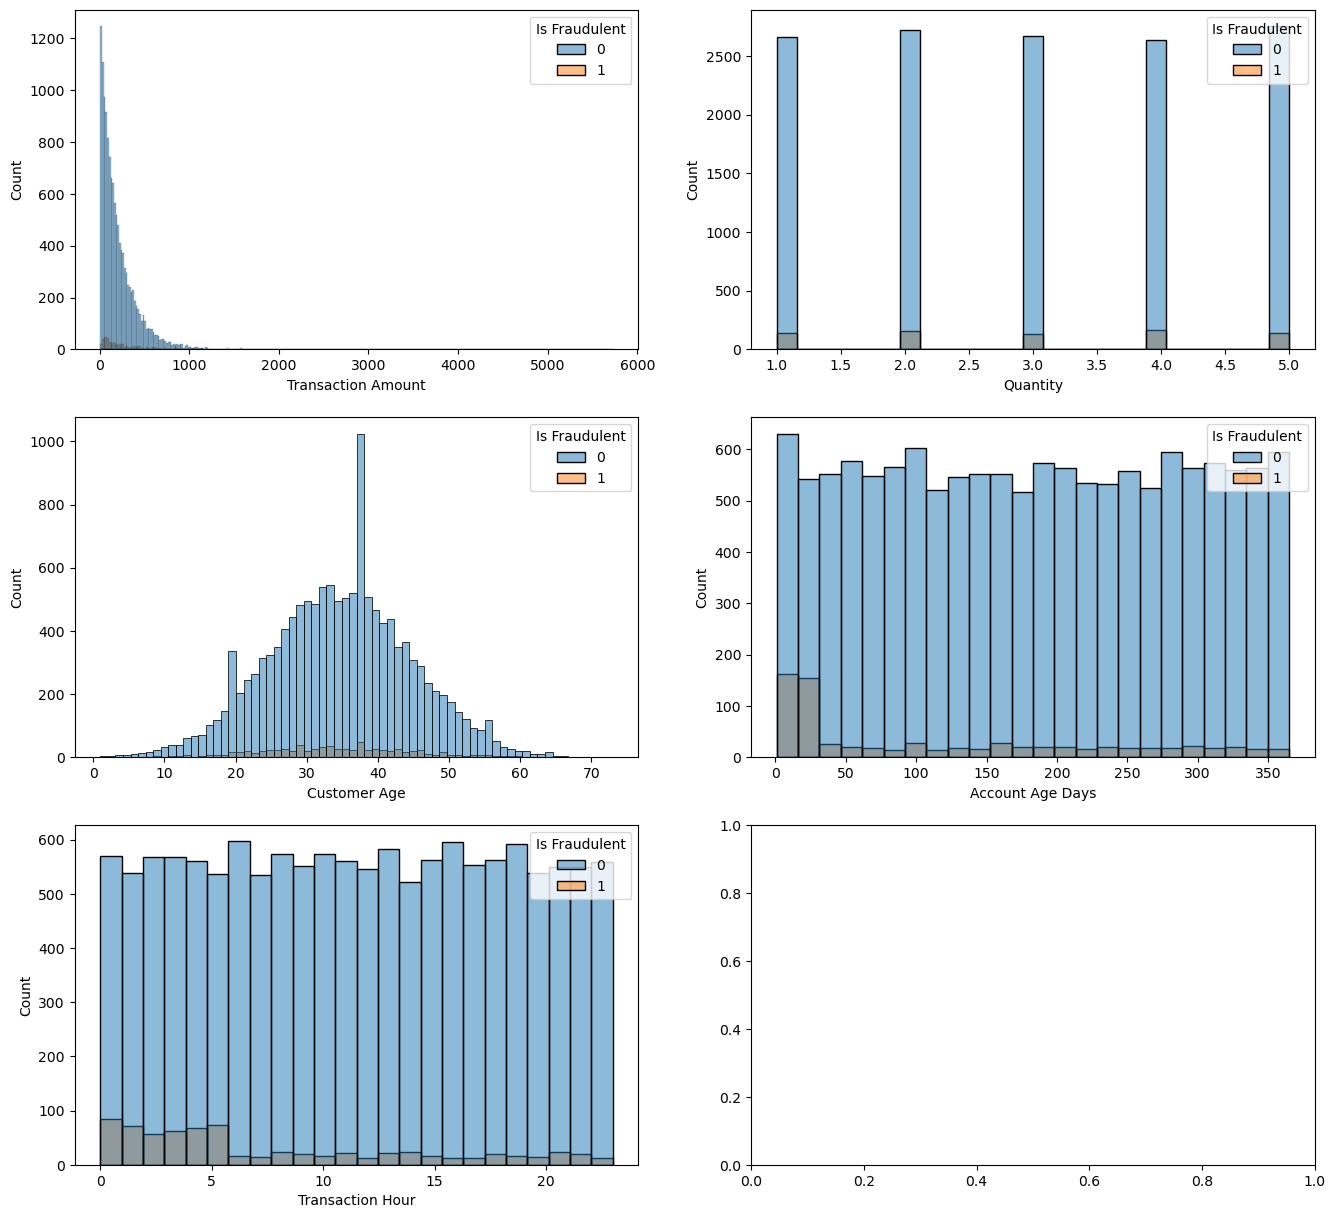

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
cols_to_hist = numeric_cols

for i, col in enumerate(cols_to_hist):
    sns.histplot(data=eda_df, x=col, hue='Is Fraudulent', ax=axes.flatten()[i])

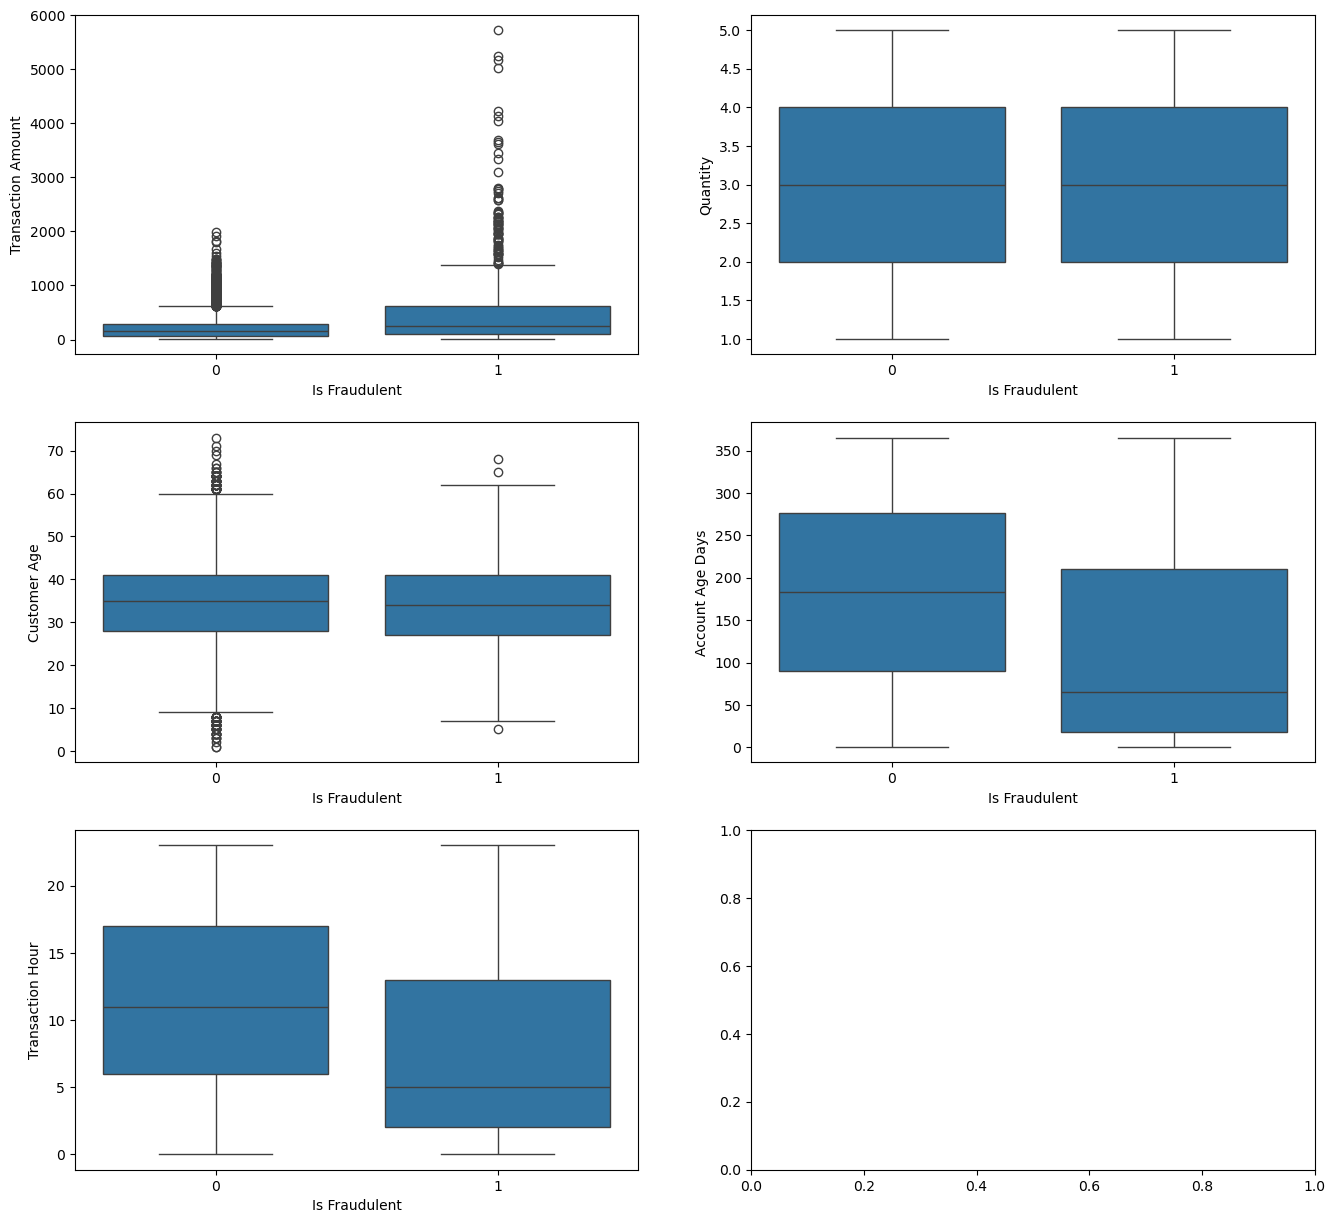

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, col in enumerate(cols_to_hist):
    sns.boxplot(data=eda_df, x='Is Fraudulent', y=col, ax=axes.flatten()[i])

Kemudian, kita lihat distribusi data kategorikal.

<Axes: xlabel='Device Used', ylabel='count'>

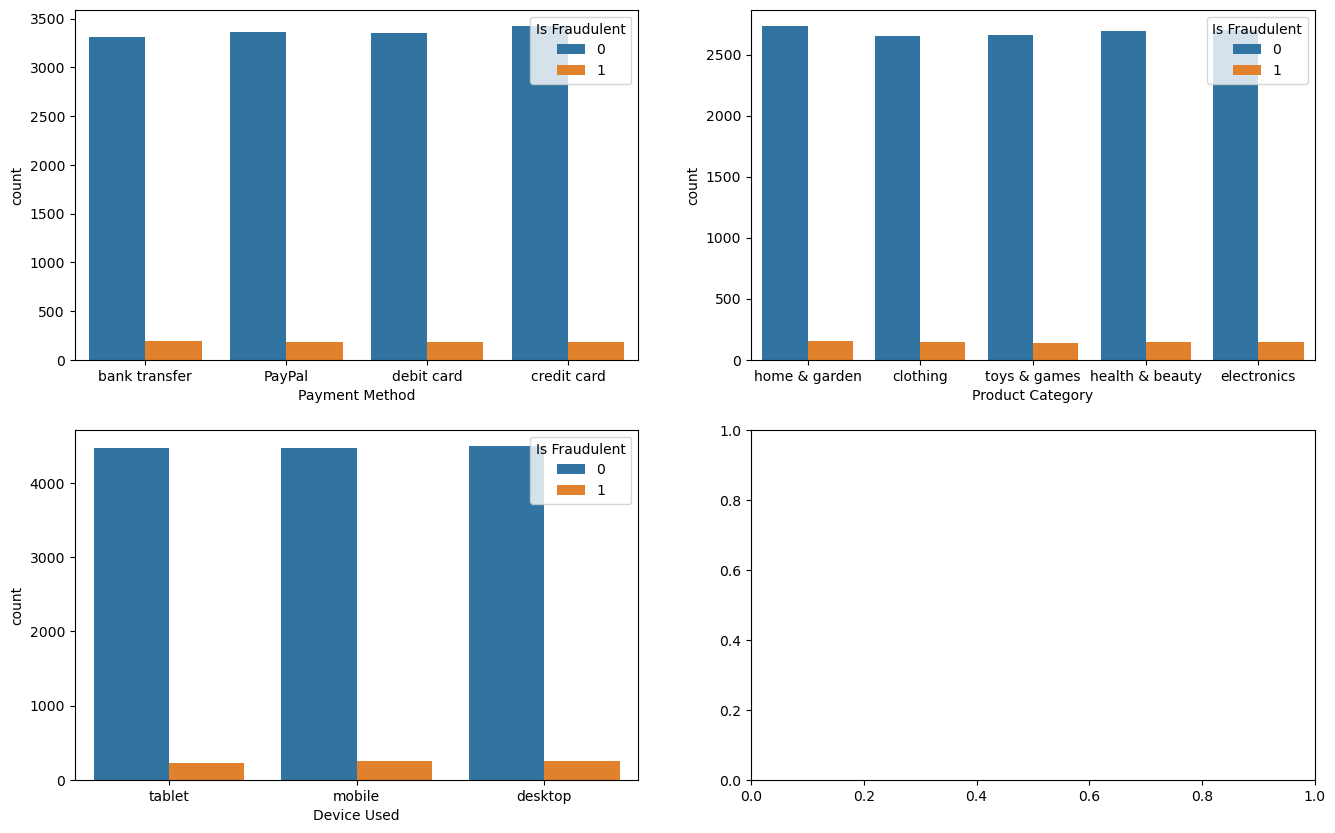

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(data=eda_df, x='Payment Method', hue='Is Fraudulent', ax=axes.flatten()[0])
sns.countplot(data=eda_df, x='Product Category', hue='Is Fraudulent', ax=axes.flatten()[1])
sns.countplot(data=eda_df, x='Device Used', hue='Is Fraudulent', ax=axes.flatten()[2])

Terakhir, kita coba analisis menggunakan correlation matrix.

Text(0.5, 1.0, 'Correlation Matrix of Numerical Variables')

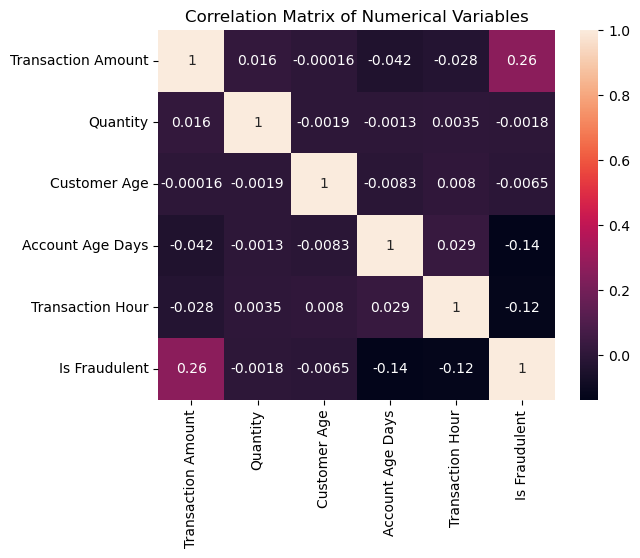

In [47]:
corr_df = eda_df[cols_to_hist+['Is Fraudulent']]
sns.heatmap(corr_df.corr(), annot=True)
plt.title('Correlation Matrix of Numerical Variables')

### Key Insights

- Tidak ada anomali dalam `Customer Age` baik dalam transaksi normal maupun fraud, semuanya berdistribusi normal.
- Distribusi untuk `Quantity`, `Payment Method`, `Product Category`, dan `Device Used` semuanya tersebar merata, baik dalam transaksi normal maupun fraud.
- Dari correlation matrix, terlihat ada korelasi positif (0.26) antara nilai transaksi (`Transaction Amount`) dengan kemungkinan fraudulent. Dari boxplot, terlihat bahwa transaksi fraud memiliki nilai median dan variansi transaksi lebih besar daripada transaksi normal.
- Dari correlation matrix, terlihat ada korelasi negatif (-0.14) antara usia akun (`Account Age Days`) dengan kemungkinan fraudulent. Dari boxplot dan histogram, terlihat bahwa transaksi fraud memiliki nilai median yang lebih rendah daripada transaksi normal. Artinya, transaksi fraud cenderung menggunakan akun yang baru dibuat.
- Dari correlation matrix, terlihat ada korelasi negatif (-0.12) antara waktu transaksi (`Transaction Hour`) dengan kemungkinan fraudulent. Dari boxplot dan histogram, terlihat bahwa transaksi fraud memiliki nilai median yang lebih rendah daripada transaksi normal. Artinya, transaksi fraud cenderung melakukan transaksi pada pagi hari (0-5 pagi).

## Question 3

Weight of Evidence (WOE) is a technique used to transform categorical variables into numerical values based on their relationship with the likelihood of fraud. WOE measures how much more or less likely a particular category is to be associated with fraud compared to non-fraud. Create WOE for fraud analytics case with the following steps:
- Create categorical variable from numerical variable using binning method
- Compute WOE values for each category in that variable using the WOE formula.
- Label the strength of information using IV (Information Value) using 3 categories: [strong, weak, very low]
- Based on this result, suggest what variables can be used to detect fraudulent cases.

### Categorization

In [53]:
# Create a function for binning the numerical predictor
def create_binning(data, predictor_label, num_of_bins):
    """
    Function for binning numerical predictor.

    Parameters
    ----------
    data : array like
      The name of dataset.

    predictor_label : object
      The label of predictor variable.

    num_of_bins : integer
      The number of bins.


    Return
    ------
    data : array like
      The name of transformed dataset.

    """
    # Create a new column containing the binned predictor
    data[predictor_label + "_bin"] = pd.qcut(data[predictor_label],
                                             q = num_of_bins,
                                             duplicates = "drop")

    return data

In [54]:
# Define numerical, categorical and target columns
num_col = cols_to_hist
cat_col = ['Payment Method', 'Product Category', 'Device Used']
response_variable = "Is Fraudulent"

for column in num_col:
    data_train_binned = create_binning(data = eda_df,
                                       predictor_label = column,
                                       num_of_bins = 4)

### WOE & IV

To assess the strength of each characteristic individually as a predictor of the model.

First, create a contingency table/crosstab for all predictors: numerical and categorical predictors.

In [57]:
# Define the initial empty list
crosstab_num = []

for column in num_col:
  # Create a contingency table
  crosstab = pd.crosstab(data_train_binned[column + "_bin"],
                         data_train_binned[response_variable],
                         margins = True)
  # Append to the list
  crosstab_num.append(crosstab)


# Define the initial empty list
crosstab_cat = []

for column in cat_col:

  # Create a contingency table
  crosstab = pd.crosstab(data_train_binned[column],
                         data_train_binned[response_variable],
                         margins = True)

  # Append to the list
  crosstab_cat.append(crosstab)

# Put all two in a crosstab_list
crosstab_list = crosstab_num + crosstab_cat

for i in crosstab_list:
    display(i)

Is Fraudulent,0,1,All
Transaction Amount_bin,,,
"(9.999, 68.35]",3432,112,3544
"(68.35, 151.8]",3394,151,3545
"(151.8, 296.2]",3396,146,3542
"(296.2, 5725.0]",3220,324,3544
All,13442,733,14175


Is Fraudulent,0,1,All
Quantity_bin,,,
"(0.999, 2.0]",5381,301,5682
"(2.0, 3.0]",2671,128,2799
"(3.0, 4.0]",2635,166,2801
"(4.0, 5.0]",2755,138,2893
All,13442,733,14175


Is Fraudulent,0,1,All
Customer Age_bin,,,
"(0.999, 28.0]",3635,210,3845
"(28.0, 35.0]",3544,204,3748
"(35.0, 41.0]",2943,140,3083
"(41.0, 73.0]",3320,179,3499
All,13442,733,14175


Is Fraudulent,0,1,All
Account Age Days_bin,,,
"(0.999, 85.0]",3183,390,3573
"(85.0, 179.0]",3424,122,3546
"(179.0, 274.0]",3427,115,3542
"(274.0, 365.0]",3408,106,3514
All,13442,733,14175


Is Fraudulent,0,1,All
Transaction Hour_bin,,,
"(-0.001, 5.0]",3341,415,3756
"(5.0, 11.0]",3390,114,3504
"(11.0, 17.0]",3361,98,3459
"(17.0, 23.0]",3350,106,3456
All,13442,733,14175


Is Fraudulent,0,1,All
Payment Method,,,
PayPal,3363,181,3544
bank transfer,3307,192,3499
credit card,3420,181,3601
debit card,3352,179,3531
All,13442,733,14175


Is Fraudulent,0,1,All
Product Category,,,
clothing,2656,148,2804
electronics,2700,142,2842
health & beauty,2691,145,2836
home & garden,2732,157,2889
toys & games,2663,141,2804
All,13442,733,14175


Is Fraudulent,0,1,All
Device Used,,,
desktop,4497,253,4750
mobile,4469,251,4720
tablet,4476,229,4705
All,13442,733,14175


In [58]:
# Define the initial list for WOE
WOE_list = []

# Define the initial list for IV
IV_list = []

# Perform the algorithm for all crosstab
for crosstab in crosstab_list:

  # Calculate % Good
  crosstab['p_good'] = crosstab[0]/crosstab[0]['All']

  # Calculate % Bad
  crosstab['p_bad'] = crosstab[1]/crosstab[1]['All']

  # Calculate the WOE
  crosstab['WOE'] = np.log((crosstab['p_good'] + 1e-6)/(crosstab['p_bad'] + 1e-6))  # add 1e-6 to prevent 0 division

  # Calculate the contribution value for IV
  crosstab['contribution'] = (crosstab['p_good']-crosstab['p_bad'])*crosstab['WOE']

  # Calculate the IV
  IV = crosstab['contribution'][:-1].sum()
  add_IV = {'Characteristic': crosstab.index.name,
            'Information Value': IV}

  WOE_list.append(crosstab)
  IV_list.append(add_IV)

for i in WOE_list:
    display(i)

Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Transaction Amount_bin,,,,,,,
"(9.999, 68.35]",3432,112,3544,0.255319,0.152797,0.513403,0.052635
"(68.35, 151.8]",3394,151,3545,0.252492,0.206003,0.203490,0.009460
"(151.8, 296.2]",3396,146,3542,0.252641,0.199181,0.237752,0.012710
"(296.2, 5725.0]",3220,324,3544,0.239548,0.442019,-0.612599,0.124034
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Quantity_bin,,,,,,,
"(0.999, 2.0]",5381,301,5682,0.400312,0.410641,-0.025474,0.000263
"(2.0, 3.0]",2671,128,2799,0.198706,0.174625,0.129184,0.003111
"(3.0, 4.0]",2635,166,2801,0.196027,0.226467,-0.144342,0.004394
"(4.0, 5.0]",2755,138,2893,0.204955,0.188267,0.084925,0.001417
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Customer Age_bin,,,,,,,
"(0.999, 28.0]",3635,210,3845,0.270421,0.286494,-0.057737,0.000928
"(28.0, 35.0]",3544,204,3748,0.263651,0.278308,-0.054102,0.000793
"(35.0, 41.0]",2943,140,3083,0.218941,0.190996,0.136548,0.003816
"(41.0, 73.0]",3320,179,3499,0.246987,0.244202,0.011340,0.000032
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Account Age Days_bin,,,,,,,
"(0.999, 85.0]",3183,390,3573,0.236795,0.532060,-0.809559,0.239034
"(85.0, 179.0]",3424,122,3546,0.254724,0.166439,0.425548,0.037569
"(179.0, 274.0]",3427,115,3542,0.254947,0.156889,0.485512,0.047608
"(274.0, 365.0]",3408,106,3514,0.253534,0.144611,0.561445,0.061154
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Transaction Hour_bin,,,,,,,
"(-0.001, 5.0]",3341,415,3756,0.248549,0.566166,-0.823245,0.261477
"(5.0, 11.0]",3390,114,3504,0.252195,0.155525,0.483391,0.046729
"(11.0, 17.0]",3361,98,3459,0.250037,0.133697,0.626029,0.072832
"(17.0, 23.0]",3350,106,3456,0.249219,0.144611,0.544280,0.056936
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Payment Method,,,,,,,
PayPal,3363,181,3544,0.250186,0.246930,0.013098,0.000043
bank transfer,3307,192,3499,0.246020,0.261937,-0.062692,0.000998
credit card,3420,181,3601,0.254426,0.246930,0.029905,0.000224
debit card,3352,179,3531,0.249368,0.244202,0.020933,0.000108
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Product Category,,,,,,,
clothing,2656,148,2804,0.197590,0.201910,-0.021629,0.000093
electronics,2700,142,2842,0.200863,0.193724,0.036186,0.000258
health & beauty,2691,145,2836,0.200193,0.197817,0.011941,0.000028
home & garden,2732,157,2889,0.203244,0.214188,-0.052450,0.000574
toys & games,2663,141,2804,0.198110,0.192360,0.029455,0.000169
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


Is Fraudulent,0,1,All,p_good,p_bad,WOE,contribution
Device Used,,,,,,,
desktop,4497,253,4750,0.334548,0.345157,-0.031217,0.000331
mobile,4469,251,4720,0.332465,0.342428,-0.029527,0.000294
tablet,4476,229,4705,0.332986,0.312415,0.063769,0.001312
All,13442,733,14175,1.000000,1.000000,0.000000,0.000000


In [59]:
# Put all IV in the table
IV_table = pd.DataFrame(IV_list)

IV_table

,Characteristic,Information Value
0,Transaction Amount_bin,0.198839
1,Quantity_bin,0.009185
2,Customer Age_bin,0.005568
3,Account Age Days_bin,0.385366
4,Transaction Hour_bin,0.437974
5,Payment Method,0.001373
6,Product Category,0.001124
7,Device Used,0.001937


The rule of thumb regarding IV:
- Less than 0.02 : generally unpredictive
- 0.02 to 0.1 : weak
- 0.1 to 0.3 : medium
- 0.3+ : strong

In [61]:
# Define the predictive power of each characteristic
strength = []

# Assign the rule of thumb regarding IV
for iv in IV_table['Information Value']:
    if iv < 0.02:
        strength.append('Unpredictive')
    elif iv >= 0.02 and iv < 0.1:
        strength.append('Weak')
    elif iv >= 0.1 and iv < 0.3:
        strength.append('Medium')
    else:
        strength.append('Strong')

# Assign the strength to each characteristic
IV_table = IV_table.assign(Strength = strength)

# Sort the table by the IV values
IV_table.sort_values(by='Information Value')

,Characteristic,Information Value,Strength
6,Product Category,0.001124,Unpredictive
5,Payment Method,0.001373,Unpredictive
7,Device Used,0.001937,Unpredictive
2,Customer Age_bin,0.005568,Unpredictive
1,Quantity_bin,0.009185,Unpredictive
0,Transaction Amount_bin,0.198839,Medium
3,Account Age Days_bin,0.385366,Strong
4,Transaction Hour_bin,0.437974,Strong


We have:
- 5 unpredictive
- 1 medium
- 2 strong characteristics

Based on this result, `Transaction Amount`, `Account Age Days`, and `Transaction Hour` can be used to detect fraudulent cases.

## Question 4

You are asked to use a simple and interpretable machine learning model. \
Task:
- Build a machine learning model using three predictors that have the highest information value.
- Use a model that is easy to interpret e.g. using logistic regression model.
- Interpret the model and explain how the model predicts the fraudulent transaction.

Dari hasil Question 3, kita akan pakai `Transaction Amount` $(x_{1})$, `Account Age Days` $(x_{2})$, dan `Transaction Hour` $(x_{4})$ sebagai prediktor. \
Model yang akan digunakan adalah logistic regression model. \
Sehingga, persamaan model regresi logistiknya menjadi:
$$
\text{logit} =\beta_{0} + \beta_{1}x_{1} + \beta_{2}x_{2} + \beta_{3}x_{3}
$$

In [66]:
predictors = ['Transaction Amount', 'Account Age Days', 'Transaction Hour']
X_train[predictors]

,Transaction Amount,Account Age Days,Transaction Hour
8692,223.89,212,13
1914,227.18,143,19
20699,268.61,331,0
17198,59.27,354,12
20905,1072.77,182,6
...,...,...,...
8369,215.49,304,13
16268,30.43,106,8
7856,133.73,246,22
4398,661.92,129,17


In [67]:
lr = LogisticRegression()
lr.fit(X_train[predictors], y_train)

b1_amount, b2_account_age, b3_hour = lr.coef_[0]
print(f"""
OR b1 (Transaction Amount)                     = {np.exp(b1_amount):.4f}
OR b1 (Transaction Amount for $100 Increase)   = {np.exp(b1_amount*100):.4f}
OR b2 (Account Age Days)                       = {np.exp(b2_account_age):.4f}
OR b2 (Account Age Days for 10 Days Increase)  = {np.exp(b2_account_age*10):.4f}
OR b3 (Transaction Hour)                       = {np.exp(b3_hour):.4f}
""")


OR b1 (Transaction Amount)                     = 1.0023
OR b1 (Transaction Amount for $100 Increase)   = 1.2528
OR b2 (Account Age Days)                       = 0.9940
OR b2 (Account Age Days for 10 Days Increase)  = 0.9411
OR b3 (Transaction Hour)                       = 0.9184



- Interpretasi:
> 1. Untuk kondisi yang sama, odds transaksi fraud bertambah sekitar 25% untuk setiap kenaikan nilai transaksi sebesar $100.
> 2. Untuk kondisi yang sama, odds transaksi fraud berkurang sekitar 5.9% untuk setiap kenaikan 10 hari dari usia akun.
> 3. Untuk kondisi yang sama, odds transaksi fraud berkurang sekitar 8.2% untuk setiap kenaikan satu jam dari waktu transaksi.

## Question 5

Build and evaluate two alternative machine learning models that may offer better performance. \
Task:
- Consider building two other machine learning models e.g. Decision Tree, Support Vector Machine, etc.
- Perform hyperparameter tuning to obtain best parameters for each model, Logistic Regression and two other models.
- Evaluate the model using appropriate evaluation metrics 
- Recommend the best model from the evaluation on testing data

In [71]:
model_dict = {
    'logistic regression': LogisticRegression(random_state=42),
    'decision tree': DecisionTreeClassifier(random_state=42),
    'random forest': RandomForestClassifier(random_state=42)
}

hyperparam_dict = {
    'logistic regression': {'C': [0.01, 0.1, 1, 10]},
    'decision tree': {'max_depth': [5, 10, 20]},
    'random forest': {'n_estimators': [50, 100, 300]}
}

# Perform modeling
models = []
auc_trains = []
auc_tests = []
best_params = []

for model_name in model_dict.keys():
    # Log
    print('start modeling', model_name)

    cv_ = GridSearchCV(estimator = model_dict[model_name],
                       param_grid = hyperparam_dict[model_name],
                       cv = 5,
                       scoring = 'roc_auc',
                       return_train_score = True,
                       verbose = 3)
    cv_.fit(X_train[predictors], y_train)

    auc_trains_ = cv_.cv_results_['mean_train_score'][0]
    auc_tests_ = cv_.best_score_
    best_params_ = cv_.best_params_

    # append
    models.append(model_name)
    auc_trains.append(auc_trains_)
    auc_tests.append(auc_tests_)
    best_params.append(best_params_)

    # log
    print('finish modeling', model_name)
    print('')

start modeling logistic regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ........C=0.01;, score=(train=0.773, test=0.757) total time=   0.0s
[CV 2/5] END ........C=0.01;, score=(train=0.761, test=0.801) total time=   0.0s
[CV 3/5] END ........C=0.01;, score=(train=0.770, test=0.770) total time=   0.2s
[CV 4/5] END ........C=0.01;, score=(train=0.779, test=0.733) total time=   0.0s
[CV 5/5] END ........C=0.01;, score=(train=0.766, test=0.782) total time=   0.0s
[CV 1/5] END .........C=0.1;, score=(train=0.773, test=0.757) total time=   0.0s
[CV 2/5] END .........C=0.1;, score=(train=0.761, test=0.801) total time=   0.0s
[CV 3/5] END .........C=0.1;, score=(train=0.770, test=0.770) total time=   0.0s
[CV 4/5] END .........C=0.1;, score=(train=0.779, test=0.733) total time=   0.0s
[CV 5/5] END .........C=0.1;, score=(train=0.766, test=0.782) total time=   0.0s
[CV 1/5] END ...........C=1;, score=(train=0.773, test=0.757) total time=   0.0s
[CV 2/5] END .

In [72]:
summ_exp = pd.DataFrame(
    {'model': models,
     'AUC train': auc_trains,
     'AUC test': auc_tests,
     'Best param': best_params}
)

summ_exp

,model,AUC train,AUC test,Best param
0,logistic regression,0.769775,0.768588,{'C': 0.1}
1,decision tree,0.808924,0.790295,{'max_depth': 5}
2,random forest,1.000000,0.758213,{'n_estimators': 300}


- Retraining model with best hyperparameters

In [74]:
lr_best = LogisticRegression(C = 0.1)
lr_best.fit(X_train[predictors], y_train)

dt_best = DecisionTreeClassifier(max_depth = 5)
dt_best.fit(X_train[predictors], y_train)

rf_best = RandomForestClassifier(n_estimators = 300)
rf_best.fit(X_train[predictors], y_train)

RandomForestClassifier(n_estimators=300)

### Train Set

In [76]:
def model_summary(model, model_name, X, y):
    # Given a model, predict X, then return evaluation on y
    y_pred = model.predict(X)

    # Get the eval table
    eval_dict = classification_report(y, y_pred, output_dict=True)

    # Find all metrics
    accuracy_ = eval_dict['accuracy']
    recall_ = eval_dict['1']['recall']
    precision_ = eval_dict['1']['precision']
    f1_ = eval_dict['1']['f1-score']
    auc_ = roc_auc_score(y, y_pred)

    # Get into dataframe
    summary = pd.DataFrame(
        [[accuracy_, recall_, precision_, f1_, auc_]],
        columns = ["Accuracy", "Recall", "Precision", "F1-Score", "ROC/AUC"],
        index = [model_name]
    )

    return summary

In [77]:
# Evaluate
summary_lr = model_summary(model = lr_best,
                           model_name = "Logistic Regression",
                           X = X_train[predictors],
                           y = y_train)
summary_dt = model_summary(model = dt_best,
                           model_name = "Decision Tree",
                           X = X_train[predictors],
                           y = y_train)
summary_rf = model_summary(model = rf_best,
                           model_name = "Random Forest",
                           X = X_train[predictors],
                           y = y_train)
# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_lr, summary_dt, summary_rf),
                                     axis=0)
summary_evaluation_train

,Accuracy,Recall,Precision,F1-Score,ROC/AUC
Logistic Regression,0.952663,0.102319,0.852273,0.182704,0.550676
Decision Tree,0.954638,0.144611,0.868852,0.247953,0.571710
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000


Dari hasil di atas, dapat dilihat bahwa:
- Meskipun Random Forest memiliki semua nilai metrik lebih tinggi dari model lain, bukan berarti dia lebih baik dalam mendeteksi fraud karena ini baru dilihat performa untuk train set, kita harus memvalidasinya di validation set.

### Validation Set

In [80]:
# Evaluate
summary_lr_valid = model_summary(model = lr_best,
                                 model_name = "Logistic Regression",
                                 X = X_valid[predictors],
                                 y = y_valid)
summary_dt_valid = model_summary(model = dt_best,
                                 model_name = "Decision Tree",
                                 X = X_valid[predictors],
                                 y = y_valid)
summary_rf_valid = model_summary(model = rf_best,
                                 model_name = "Random Forest",
                                 X = X_valid[predictors],
                                 y = y_valid)
# Add to summary evaluation train
summary_evaluation_valid = pd.concat((summary_lr_valid, summary_dt_valid, summary_rf_valid),
                                     axis=0)
summary_evaluation_valid

,Accuracy,Recall,Precision,F1-Score,ROC/AUC
Logistic Regression,0.953439,0.122449,0.857143,0.214286,0.560666
Decision Tree,0.952381,0.155102,0.678571,0.252492,0.575542
Random Forest,0.951534,0.191837,0.602564,0.291022,0.592459


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk validation set mirip dengan train set kecuali untuk model Random Forest.
- Meskipun begitu, model Random Forest masih memiliki nilai Recall, F1-Score, dan ROC-AUC yang lebih tinggi. Artinya, model ini lebih baik dalam mendeteksi fraud.
- Kita akan menggunakan model Random Forest untuk test set.

### Test Set

In [83]:
summary_rf_valid = model_summary(model = rf_best,
                                 model_name = "Random Forest - VALID",
                                 X = X_valid[predictors],
                                 y = y_valid)
summary_rf_test = model_summary(model = rf_best,
                                model_name = "Random Forest - TEST",
                                X = X_test[predictors],
                                y = y_test)
summary_test = pd.concat((summary_rf_valid, summary_rf_test),
                         axis=0)
summary_test

,Accuracy,Recall,Precision,F1-Score,ROC/AUC
Random Forest - VALID,0.951534,0.191837,0.602564,0.291022,0.592459
Random Forest - TEST,0.951534,0.225410,0.578947,0.324484,0.608242


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk test set mirip dengan validation set.

## Question 6

When building a logistic regression model, the output is a probability of a transaction being a fraud. The challenge often lies in choosing a threshold probability that classifies predictions as either fraud (1) or legitimate (0). This threshold directly influences the model's performance, particularly when dealing with different costs associated with false positives and false negatives.

There are two options to select best threshold:
1. Minimizing false negatives (i.e., ensuring all fraud cases are caught).
2. Minimizing false positives (i.e., ensuring legitimate transactions are not mistakenly flagged as fraud)

Task:
- Using the logistic regression model from the previous question, evaluate some threshold probabilities to predict fraud. Here’s an example of result:
|Threshold|FN Cost|FP Cost|Total Cost|
|:--|:--|:--|:--|
|0.3||||
|0.5||||
|0.7||||
- Explain how the threshold affects the model's classification of fraud and legitimate transactions, particularly in relation to the associated costs (fraud losses, profit loss and customer acquisition losses).
    - False negatives cost: Fraud loss, represented by the total amount of money exchange in transactions for ignored fraud cases.
    - False positives cost: Losses from profit (5% of the total amount of money) and customer acquisition costs ($15 per customer).
- Recommend the best threshold if the company tends to prioritize ensuring all fraud cases are caught.

### Train Set

In [88]:
# Create a function to summarize prediction results
def cross_tab(y_act, y_pred):
    """
    Summarize the prediction results

    Parameters
    ----------
    y_act : array-like
        The true target (y actual)

    y_pred : array-like
        The predicted

    Return
    ------
    crosstab_table : pd.DataFrame
        The crosstab table (confusion matrix)
        [[TP, FN],
         [FP, TN]]
    """
    # Extract the prediction
    fp = np.sum((y_act == 0) & (y_pred == 1))  # False positive
    tp = np.sum((y_act == 1) & (y_pred == 1))  # True positive
    fn = np.sum((y_act == 1) & (y_pred == 0))  # False negative
    tn = np.sum((y_act == 0) & (y_pred == 0))  # True negative

    # Summarize
    crosstab_table = pd.DataFrame(
        data = [[tp, fn], [fp, tn]],
        columns = ["Predicted Fraud", "Predicted Non Fraud"],
        index = ["Actual Fraud", "Actual Non Fraud"]
    )

    return crosstab_table

In [89]:
# Calculate the loss from false prediction
def loss(eval_table, df, y_true, y_pred):
    """
    Calculate the business-side cost of the model

    Parameters
    ----------
    eval_table : {array-like} of shape (n_class,n_class)
        Evaluation table, where `n_class` is the number of class
    df         : Pandas DataFrame
        The data input
    y_true     : Pandas Series
        The data actual output
    y_pred     : numpy.ndarray
        The data predicted output

    Returns
    --------
    cost: float
        The total cost according to business assumptions
    """
    # Get the number of false negative and false positive
    fp = eval_table.loc["Actual Non Fraud", "Predicted Fraud"]

    # Define cost
    cost_acquired = 15     # average cost to acquire new user

    # Calculate the total cost
    fn_cost = df.loc[(y_true == 1) & (y_pred == 0), 'Transaction Amount'].sum()
    fp_cost = 0.05 * df.loc[(y_true == 0) & (y_pred == 1), 'Transaction Amount'].sum() + (fp * cost_acquired)
    total_cost = fn_cost + fp_cost

    return fn_cost, fp_cost, total_cost

In [90]:
# Ambil nilai transaksi dan label asli untuk mempermudah perhitungan
X = X_train
y_actual = y_train

# Mendapatkan probabilitas prediksi dari model Logistic Regression yang sudah dibuat (lr_best)
y_prob = lr_best.predict_proba(X[predictors])[:, 1]

# Menentukan threshold
thresholds = np.arange(0.05, 1.0, 0.05)
cost_results = []

for t in thresholds:
    # Klasifikasi predikasi berdasarkan threshold
    y_pred = (y_prob >= t).astype(int)
    eval_table = cross_tab(y_actual, y_pred)
    
    fn_cost, fp_cost, total_cost = loss(eval_table, X, y_actual, y_pred)
    
    cost_results.append({
        'Threshold': t,
        'FN Cost ($)': np.round(fn_cost, 2),
        'FP Cost ($)': np.round(fp_cost, 2),
        'Total Cost ($)': np.round(total_cost, 2)
    })

# Menampilkan hasil
cost_df = pd.DataFrame(cost_results)
cost_df

,Threshold,FN Cost ($),FP Cost ($),Total Cost ($)
0,0.05,38438.38,122359.19,160797.57
1,0.10,80695.57,50602.09,131297.66
2,0.15,112892.10,23724.23,136616.33
3,0.20,139187.75,12041.91,151229.66
4,0.25,157197.29,7476.87,164674.16
5,0.30,175656.49,4804.79,180461.28
6,0.35,184382.27,3361.84,187744.11
7,0.40,195341.26,2017.26,197358.52
8,0.45,209064.46,1530.37,210594.83
9,0.50,213868.46,1116.59,214985.05


Threshold dapat mempengaruhi model dalam mengklasifikasi transaksi fraud sebagai berikut:
- Jika threshold diatur rendah (Misal 0.1), maka model akan menjadi sangat sensitif. Artinya, jika sedikit saja ada probability transaksi fraud (prob > 0.1), model akan mengklasifikasikan transaksi sebagai fraud (1). Sehingga, banyak transaksi fraud yang berhasil ditemukan (False Negative jauh berkurang) namun banyak juga transaksi normal yang salah dideteksi sebagai fraud (False Positive jauh bertambah).
- Jika threshold diatur tinggi (Misal 0.8), maka model akan menjadi tidak sensitif. Artinya, model hanya akan mengklasifikasikan transaksi sebagai fraud (1) jika probability transaksi akan fraud cukup besar (prob > 0.8). Sehingga, banyak transaksi fraud yang tidak berhasil ditemukan (False Negative jauh bertambah) namun transaksi normal lebih sedikit yang salah dideteksi sebagai fraud (False Positive jauh berkurang).
- Karena perusahaan ingin mendeteksi kasus fraud sebanyak mungkin (meminimalkan False Negative), maka model ini akan menggunakan threshold yang rendah. Dari hasil di atas, kemungkinan threshold yang akan digunakan adalah 0.10. Tetapi, ini baru dilihat performanya untuk train set, kita harus memvalidasinya di validation set.

### Validation Set

In [93]:
# Ambil nilai transaksi dan label asli untuk mempermudah perhitungan
X = X_valid
y_actual = y_valid

# Mendapatkan probabilitas prediksi dari model Logistic Regression yang sudah dibuat (lr_best)
y_prob = lr_best.predict_proba(X[predictors])[:, 1]

# Menentukan threshold
thresholds = np.arange(0.05, 1.0, 0.05)
cost_results = []

for t in thresholds:
    # Klasifikasi predikasi berdasarkan threshold
    y_pred = (y_prob >= t).astype(int)
    eval_table = cross_tab(y_actual, y_pred)
    
    fn_cost, fp_cost, total_cost = loss(eval_table, X, y_actual, y_pred)
    
    cost_results.append({
        'Threshold': t,
        'FN Cost ($)': np.round(fn_cost, 2),
        'FP Cost ($)': np.round(fp_cost, 2),
        'Total Cost ($)': np.round(total_cost, 2)
    })

# Menampilkan hasil
cost_df = pd.DataFrame(cost_results)
cost_df

,Threshold,FN Cost ($),FP Cost ($),Total Cost ($)
0,0.05,14069.65,39281.50,53351.15
1,0.10,28293.32,16037.78,44331.10
2,0.15,38078.51,7340.82,45419.33
3,0.20,46676.77,4221.36,50898.14
4,0.25,56622.37,2334.32,58956.69
5,0.30,61761.32,1456.38,63217.70
6,0.35,65100.87,1200.77,66301.64
7,0.40,69392.47,807.82,70200.29
8,0.45,74370.22,595.20,74965.42
9,0.50,80692.32,387.77,81080.09


Dari sini, dapat dilihat bahwa threshold 0.10 memberikan hasil total cost yang terendah untuk validation set. \
Kita akan menggunakan threshold ini pada test set.

### Test Set

In [96]:
# Ambil nilai transaksi dan label asli untuk mempermudah perhitungan
X = X_test
y_actual = y_test

# Mendapatkan probabilitas prediksi dari model Logistic Regression yang sudah dibuat (lr_best)
y_prob = lr_best.predict_proba(X[predictors])[:, 1]

# Menentukan threshold
thresholds = [0.10]
cost_results = []

for t in thresholds:
    # Klasifikasi predikasi berdasarkan threshold
    y_pred = (y_prob >= t).astype(int)
    eval_table = cross_tab(y_actual, y_pred)
    
    fn_cost, fp_cost, total_cost = loss(eval_table, X, y_actual, y_pred)
    
    cost_results.append({
        'Threshold': t,
        'FN Cost ($)': np.round(fn_cost, 2),
        'FP Cost ($)': np.round(fp_cost, 2),
        'Total Cost ($)': np.round(total_cost, 2)
    })

# Menampilkan hasil
cost_df = pd.DataFrame(cost_results)
cost_df

,Threshold,FN Cost ($),FP Cost ($),Total Cost ($)
0,0.1,23419.42,16914.87,40334.29


Total cost untuk threshold 0.10 pada test set adalah \$40,334.29.

## Question 7

Using logistic regression with the best threshold obtained in Question 6, the company needs to consider the cost of incorrect predictions (i.e., false positives and false negatives) and evaluate the total cost that the model incurs in the testing data. \
Task
- Make prediction on testing data and make summary of evaluation using some performance metric
- How much cost does the model give to the company from the correct and wrong predictions, assume
  - Cost of fraudulent cases: the total amount of money exchanged in the transaction.
  - Average cost to acquire a new user: $15 per customer
  - Average loss of potential profit: 5% of the total amount of money exchange per transaction
- Create a summary table of the evaluation. Does the model with the best threshold outperform the total cost of all wrong predictions?
|Models|Total Cost|
|:--|:--|
|Baseline||
|Logistic Regression with Best Threshold||

In [100]:
def model_summary(model_name, X, y, y_pred):
    
    # Get the classification report
    eval_dict = classification_report(y, y_pred, output_dict=True, zero_division=0.0)
    eval_table = cross_tab(y, y_pred)

    # Find all metrics
    accuracy_ = eval_dict['accuracy']
    recall_ = eval_dict['1']['recall']
    precision_ = eval_dict['1']['precision']
    f1_ = eval_dict['1']['f1-score']
    auc_ = roc_auc_score(y, y_pred)
    fn, fp, cost_ = loss(eval_table = eval_table,
                         df = X,
                         y_true = y,
                         y_pred = y_pred)

    # Get into dataframe
    summary = pd.DataFrame(
        [[accuracy_, recall_, precision_, f1_, auc_, cost_]],
        columns = ["Accuracy", "Recall", "Precision", "F1-Score", "ROC-AUC", "Total Cost"],
        index = [model_name]
    )

    return summary

In [101]:
summary_lr = model_summary("Logistic Regression with Best Threshold", X_test, y_test, y_pred)
summary_lr

,Accuracy,Recall,Precision,F1-Score,ROC-AUC,Total Cost
Logistic Regression with Best Threshold,0.881481,0.52459,0.223776,0.313725,0.712753,40334.2905


In [102]:
# Create model
base_clf = DummyClassifier(strategy = "most_frequent")

# Fit
base_clf.fit(X_train, y_train)

# Evaluate
y_pred_base = base_clf.predict(X_test)
summary_baseline = model_summary(model_name = "Baseline",
                                 X = X_test,
                                 y = y_test,
                                 y_pred = y_pred_base)
summary_baseline

,Accuracy,Recall,Precision,F1-Score,ROC-AUC,Total Cost
Baseline,0.94836,0.0,0.0,0.0,0.5,147938.82


In [103]:
summary_evaluation_test = pd.concat((summary_baseline, summary_lr), axis=0)
summary_evaluation_test

,Accuracy,Recall,Precision,F1-Score,ROC-AUC,Total Cost
Baseline,0.948360,0.00000,0.000000,0.000000,0.500000,147938.8200
Logistic Regression with Best Threshold,0.881481,0.52459,0.223776,0.313725,0.712753,40334.2905


Dari hasil di atas, dapat dilihat bahwa model Logistic Regression with Best Threshold memiliki performa yang jauh lebih baik dari Baseline Model. \
Jika perusahaan tidak menggunakan model untuk mendeteksi fraud, kerugian total akibat seluruh transaksi fraud mencapai \$147,938.82.


Namun, dengan menggunakan model Logistic Regression, meskipun nilai akurasinya lebih rendah, nilai recallnya (0.52) jauh lebih tinggi dari baseline model (artinya model dapat mendeteksi 52 kasus fraud dari 100 kasus fraud yang ada) sehingga total kerugiannya dapat ditekan hingga menjadi hanya \$40,334.29, berkurang 73% dari sebelumnya.

## Question 8

Fraud detection models might minimize fraud losses. However, to build a model there are other costs that should be paid, model ownership costs, and fraud handling costs. To assess the benefit of models, we can calculate the Return on Investment of the model. **ROI** is calculated as the ratio of net profit (benefit minus costs) to total investment, expressed as a percentage. \
$$
\text{ROI} = \frac{\text{Total Utility}}{\text{Total cost of ownership} + \text{Total cost of fraud handling}}
$$

Task: Calculate the ROI of the best model from Question 5 using the following detail:
- Total Utility is the net return, which is the difference between the benefits (True Positives and True Negatives) and the costs (False Negatives and False Positives).
  - Costs are as follows:
    - False Negatives (FN): Fraud loss, represented by the total amount of money exchange in transactions for ignored fraud cases.
    - False Positives (FP): Losses from profit and customer acquisition costs.
  - **Benefits** include: 
    - True Positives (TP): Prevented fraud losses, represented by  the total amount of money exchanged in transactions .
    - True Negatives (TN): Generated profit from legitimate transactions.
- The **total cost of ownership** consists of acquisition costs (**\$30,000** for software, hardware, security, and development) and operation costs (**\$20,000** for migration, setup, monitoring, and support).
- **Total Cost of Fraud Handling.** Ensure that the costs of fraud handling, such as fraud inspection and legal costs, are included. Use the provided cost values for fraud inspection, fraud handling, and legal costs when calculating:
  - Fraud inspection per transaction that are predicted as fraud: \$200
  - Fraud handling cost per truly fraud transaction: \$300
  - Legal cost: \$500

### **1. Total Utility**

In [108]:
# Make prediction
y_pred_test = rf_best.predict(X_test[predictors])

# Get the eval table
eval_table_test = cross_tab(y_test, y_pred_test)

# Show the result of prediction
eval_table_test

,Predicted Fraud,Predicted Non Fraud
Actual Fraud,55,189
Actual Non Fraud,40,4441


In [109]:
# define the correct prediction in each class
tp = eval_table_test.loc["Actual Fraud", "Predicted Fraud"]
tn = eval_table_test.loc["Actual Non Fraud", "Predicted Non Fraud"]

# define the false prediction in each class
fp = eval_table_test.loc["Actual Non Fraud", "Predicted Fraud"]
fn = eval_table_test.loc["Actual Fraud", "Predicted Non Fraud"]

- Let's simulate this metric, assume
  - Average cost of fraudulent cases: Corresponding `Transaction Amount` per fraud case
  - Average cost to acquire new user: \$15/user
  - Average potential profit: 5% of the corresponding `Transaction Amount` per transaction

In [111]:
fn_cost, fp_cost, cost = loss(eval_table = eval_table_test, 
                              df = X_test, 
                              y_true = y_test, 
                              y_pred = y_pred_test)
cost

58871.09100000001

In [112]:
# Calculate the total benefit
tp_benefit = X_test.loc[(y_test == 1) & (y_pred_test == 1), 'Transaction Amount'].sum()
tn_benefit = 0.05 * X_test.loc[(y_test == 0) & (y_pred_test == 0), 'Transaction Amount'].sum()
benefit = tp_benefit + tn_benefit
benefit

137370.1825

Calculate the total utility as substraction Benefit and Cost as representation of total return.
- Cost is in negative form since it's the amount we should lose in return we use the model
- Benefit is in positive form since it's the amount we can get in return we use the model

In [114]:
# Calculate the total utility
total_utility = benefit - cost
total_utility

78499.09149999998

### **2. Total Cost of Ownership**

- The details of component we need to calculate the total cost of ownership depends on the company and industry
- In this section, assume the cost of ownership we have comes from
  - Acquisition Costs (software, hardware cost, network and security cost, model developer cost): `$30,000`
  - Operation Costs (Model Migration, Setup, Monitoring, and Support Costs): `$20,000`

In [117]:
# Calculate the total cost of ownership
acq_cost = 30_000
op_cost = 20_000

total_cost_of_ownership = acq_cost + op_cost
total_cost_of_ownership

50000

### **3. Total Cost of Fraud Handling**

- The total cost of fraud handling include inspection costs, legal costs.
- We assume:
  - Fraud inspection per transaction that are predicted as fraud: \$200
  - Fraud handling cost per truly fraud transaction: \$300
  - Legal cost: \$500

In [120]:
# Calculate the total cost of Fraud Handling
ins_cost = (tp+fp) * 200
handle_cost = tp*300
legal_cost = 500
total_cost_of_fraud_handling = ins_cost + handle_cost + legal_cost
total_cost_of_fraud_handling

36000

### **4. Calculate ROI**

In [122]:
roi = (total_utility/(total_cost_of_ownership + total_cost_of_fraud_handling))*100
roi

91.278013372093

The Return of Investment of Random Forest Model is 91.00%.